# YIELDMAP — Dubai property investment intelligence

**AI 217, AI in Finance · SP Jain MAIB · Krishna Mathur**

This notebook is the evidence behind the report. Every number in it is read from `docs/results/`,
which is written by the models in `finance/`, which read the database built by `etl/`. Nothing is
typed in by hand, so a figure here and a figure in the report cannot disagree.

> **Information, not advice.** Everything here explains, compares or simulates. None of it is a
> recommendation to buy, sell or finance anything.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "docs" else Path.cwd()
REAL = ROOT / "docs" / "results"
SYNTHETIC = REAL / "synthetic"

# Prefer real results; fall back to the labelled stand-in and say so loudly.
SOURCE = REAL if (REAL / "hedonic.json").exists() else SYNTHETIC
PROVENANCE = "REAL" if SOURCE == REAL else "SYNTHETIC"


def result(name):
    path = SOURCE / name
    if not path.exists():
        raise FileNotFoundError(f"{name} has not been produced yet; run the model that writes it")
    return json.loads(path.read_text())


plt.rcParams.update(
    {
        "figure.figsize": (10, 4.5),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)
TEAL, SAND, GRAPHITE = "#1f7a70", "#c9a227", "#2b2b2b"

print(f"Reading results from: {SOURCE.relative_to(ROOT)}")
print(f"Provenance: {PROVENANCE}")

Reading results from: docs/results/synthetic
Provenance: SYNTHETIC


In [2]:
if PROVENANCE == "SYNTHETIC":
    print("=" * 78)
    print("  THESE FIGURES COME FROM GENERATED DATA, NOT FROM THE DUBAI REGISTRY.")
    print()
    print("  Dubai Pulse, which publishes the bulk DLD CSVs, refuses connections from")
    print("  automated clients, so the pipeline is running on a labelled stand-in whose")
    print("  structure is realistic and whose levels are invented. The methods, the tests")
    print("  and the code paths below are exactly those that will run on real data; the")
    print("  numbers are not statements about Dubai and must not be cited as such.")
    print()
    print("  docs/datasets.md records the evidence and the steps to load the real files.")
    print("=" * 78)

  THESE FIGURES COME FROM GENERATED DATA, NOT FROM THE DUBAI REGISTRY.

  Dubai Pulse, which publishes the bulk DLD CSVs, refuses connections from
  automated clients, so the pipeline is running on a labelled stand-in whose
  structure is realistic and whose levels are invented. The methods, the tests
  and the code paths below are exactly those that will run on real data; the
  numbers are not statements about Dubai and must not be cited as such.

  docs/datasets.md records the evidence and the steps to load the real files.


## 1. The data

The registry is the whole point: unit-level, daily, public. What follows describes what actually
landed rather than what the documentation claims is available.

In [3]:
clean = result("clean.json")
publish = result("publish.json")

for table, info in clean["tables"].items():
    print(f"{table:>16}: {info['rows_in']:>9,} rows in -> {info['rows_out']:>9,} kept")

print()
print(
    f"{'areas':>16}: {publish['areas']} ({publish['areas_with_location']} with a mapped centroid)"
)
for f in publish["freshness"]:
    print(f"{f['table_name']:>16}: latest record {f['as_of']}, provenance {f['provenance']}")

    transactions:   120,346 rows in ->   120,346 kept
  rent_contracts:    90,000 rows in ->    90,000 kept

           areas: 86 (86 with a mapped centroid)
    transactions: latest record 2025-12-30, provenance SYNTHETIC
  rent_contracts: latest record 2025-12-30, provenance SYNTHETIC


### Coverage of the area mapping

The 3D map extrudes communities by metric. An area the registry reports but the project has no
coordinate for is rendered without a location rather than dropped or placed at the origin — the
coverage figure below is what makes that honest.

In [4]:
coverage = clean.get("area_coverage")
if coverage:
    print(f"areas in the data:      {coverage['areas_in_data']}")
    print(
        f"with a curated centroid: {coverage['areas_with_centroid']} ({coverage['coverage']:.0%})"
    )
    if coverage["n_missing_centroid"]:
        print(f"missing:                 {coverage['n_missing_centroid']}")
        for name in coverage["missing_centroid"][:10]:
            print(f"    {name}")

areas in the data:      86
with a curated centroid: 86 (100%)


## 2. Hedonic valuation

A gradient-boosted regressor on the characteristics the registry records, predicting log price per
square metre. Two choices decide whether the result means anything.

**The target is per square metre, in logs.** Prices span three orders of magnitude; squared error
on the raw figure would let a handful of penthouses dominate the fit. Predictions are transformed
back with Duan's smearing correction, without which the back-transform is biased low.

**The holdout is the most recent year, not a random split.** A random split lets the model see this
year's sales while predicting this year's sales. It flatters the model enormously and answers a
question nobody has.

In [5]:
h = result("hedonic.json")["metrics"]

print(f"trained on {h['n_train']:,} sales, {h['train_period'][0]} to {h['train_period'][1]}")
print(f"tested on  {h['n_test']:,} sales, {h['test_period'][0]} to {h['test_period'][1]}")
print()
print(f"  model MAPE on the holdout        {h['test']['mape']:.1%}")
print(f"  median absolute percentage error {h['test']['median_ape']:.1%}")
print(f"  baseline MAPE                    {h['baseline']['mape']:.1%}")
print(f"    ({h['baseline']['method']})")
print(f"  skill against the baseline       {h['skill_vs_baseline']:+.1%}")
print(f"  estimated irreducible noise      {h['estimated_noise_floor_mape']:.1%}")

trained on 110,407 sales, 2014-01-01 to 2024-12-31
tested on  9,939 sales, 2025-01-01 to 2025-12-30

  model MAPE on the holdout        18.9%
  median absolute percentage error 16.2%
  baseline MAPE                    36.4%
    (median price per sqm for the same area, type and bedroom count)
  skill against the baseline       +48.1%
  estimated irreducible noise      19.4%


The comparison is the point. An absolute error target means little without knowing what a careful
person with a spreadsheet would achieve, and without knowing how much of the remaining error is
irreducible scatter in the data itself. Reporting all three makes the model's contribution legible.

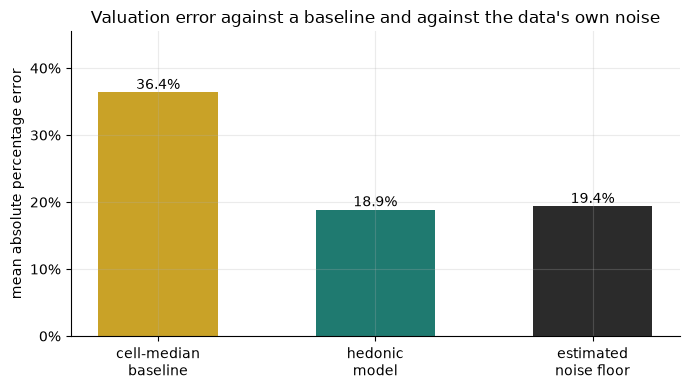

In [6]:
labels = ["cell-median\nbaseline", "hedonic\nmodel", "estimated\nnoise floor"]
values = [h["baseline"]["mape"], h["test"]["mape"], h["estimated_noise_floor_mape"]]
colours = [SAND, TEAL, GRAPHITE]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colours, width=0.55)
for bar, v in zip(bars, values, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)
ax.set_ylabel("mean absolute percentage error")
ax.set_title("Valuation error against a baseline and against the data's own noise")
ax.set_ylim(0, max(values) * 1.25)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.tight_layout()
plt.show()

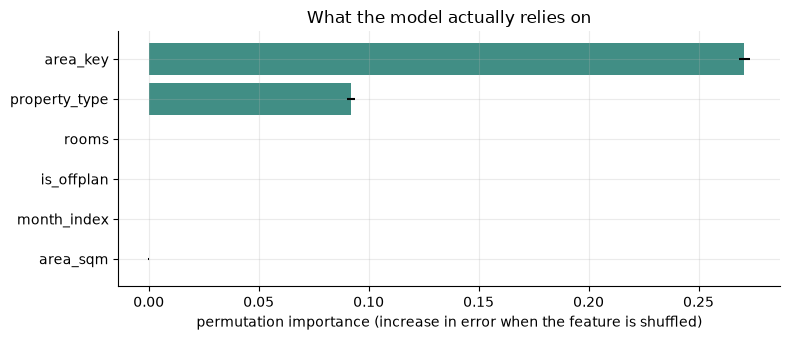

In [7]:
imp = h["importance"]
fig, ax = plt.subplots(figsize=(8, 3.5))
names = [d["feature"] for d in imp][::-1]
vals = [d["importance"] for d in imp][::-1]
errs = [d["std"] for d in imp][::-1]
ax.barh(names, vals, xerr=errs, color=TEAL, alpha=0.85)
ax.set_xlabel("permutation importance (increase in error when the feature is shuffled)")
ax.set_title("What the model actually relies on")
plt.tight_layout()
plt.show()

## 3. Repeat-sales index

A median price per square metre moves when the *mix* of what sold changes, not only when prices
change. A quarter in which three towers complete and a hundred studios transact shows a falling
median even if every individual property is worth more. Comparing each property against itself
cancels composition out.

The estimator is Bailey–Muth–Nourse, the method underneath the Case–Shiller family, weighted by the
inverse holding period because a pair spanning eight years carries far more idiosyncratic noise
than one spanning eight months.

In [8]:
idx = result("index.json")
d = idx["diagnostics"]

print(f"{d['n_pairs']:,} repeat-sale pairs across {d['n_periods']} months")
print(f"  median holding period            {d['median_hold_days']:,.0f} days")
print(f"  periods dropped as disconnected  {d['periods_dropped_as_disconnected']}")
print(f"  thin periods                     {d['thin_periods']}")
print()
print("  year   index   growth      pairs")
for row in idx["annual"]:
    growth = "     —" if row["growth"] is None else f"{row['growth']:+6.1%}"
    print(f"  {row['year']}  {row['index']:7.1f}  {growth}  {row['n_pairs']:>9,}")

5,079 repeat-sale pairs across 144 months
  median holding period            1,302 days
  periods dropped as disconnected  0
  thin periods                     0

  year   index   growth      pairs
  2014    109.4       —        831
  2015    111.0   +1.5%        775
  2016    105.0   -5.5%        824
  2017    102.5   -2.4%        860
  2018     94.6   -7.7%        803
  2019     89.7   -5.2%        882
  2020     83.8   -6.5%        879
  2021     84.8   +1.2%        876
  2022     95.3  +12.4%        854
  2023    110.2  +15.6%        868
  2024    129.1  +17.1%        913
  2025    153.6  +18.9%        793


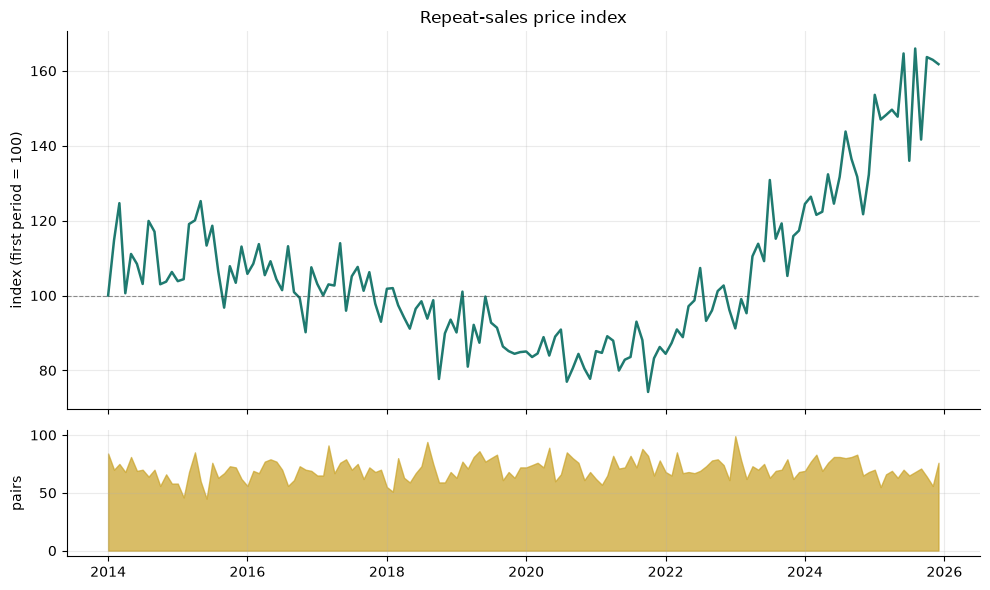

In [9]:
series = idx["series"]
months = [np.datetime64(r["period"]) for r in series]
levels = [r["index"] for r in series]
pairs = [r["n_pairs"] for r in series]

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
ax.plot(months, levels, color=TEAL, linewidth=1.8)
ax.axhline(100, color=GRAPHITE, linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_ylabel("index (first period = 100)")
ax.set_title("Repeat-sales price index")

ax2.fill_between(months, pairs, color=SAND, alpha=0.7)
ax2.set_ylabel("pairs")
ax2.set_xlabel("")
plt.tight_layout()
plt.show()

### Why connectivity matters

A repeat-sales index is only identified within a connected set of periods. If January-to-July pairs
and February-to-August pairs never meet, the relative level of the two chains is genuinely
unknowable — but least squares will still return an answer by quietly taking the minimum-norm
solution, presenting an artefact as a measurement. The estimator finds the connected components
explicitly and reports what it dropped.

## 4. Gross and net yield

Gross yield is what every portal quotes and is close to meaningless alone: it ignores the service
charge, the transfer fee, the months a unit sits empty and the cost of managing it. Every input
behind the net figure lives in `config/assumptions.yaml` with a status saying how well founded it is.

In [10]:
y = result("yield.json")
s = y["summary"]

print(f"{s['cells']} area-type-bedroom cells, {s['cells_published']} published")
print(f"{s['cells_suppressed_for_thin_data']} suppressed as too thin to report")
print()
print(f"  median gross yield  {s['median_gross_yield']:.2%}")
print(f"  median net yield    {s['median_net_yield']:.2%}")
print(f"  median gap          {s['median_spread']:.2%}")
print()
print("  assumptions behind the net figure")
for row in y["assumptions"]:
    value = row["value"]
    shown = f"{value:,.4g}" if isinstance(value, (int, float)) else str(value)
    print(f"    {row['label']:<44} {shown:>10}  [{row['status']}]")

463 area-type-bedroom cells, 348 published
115 suppressed as too thin to report

  median gross yield  7.12%
  median net yield    3.43%
  median gap          3.59%

  assumptions behind the net figure
    Vacancy allowance                                  0.08  [estimate]
    Service charge                                      160  [estimate]
    Property management                                0.05  [estimate]
    Maintenance and repairs                            0.01  [estimate]
    DLD transfer fee                                   0.04  [unverified]
    Agent commission                                   0.02  [estimate]
    Registration and trustee fees                     4,200  [unverified]
    Holding period for amortising purchase costs          7  [estimate]


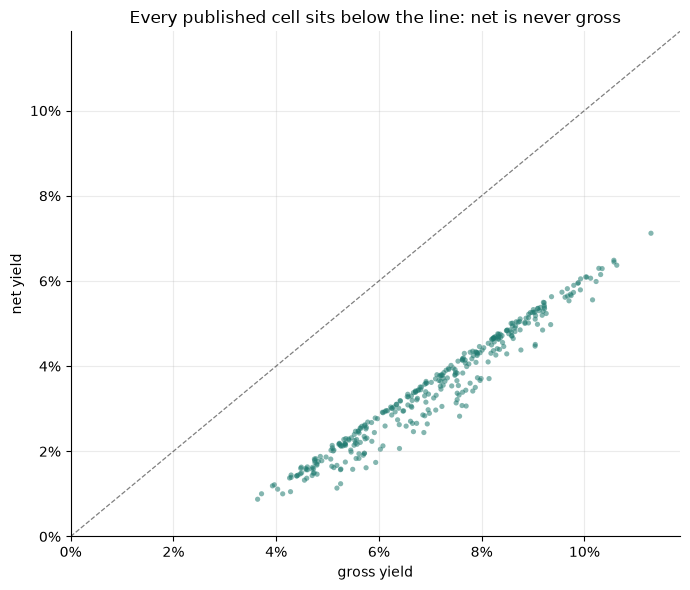

cells where net exceeds gross: 0


In [11]:
table = y["table"]
gross = [r["gross_yield"] for r in table]
net = [r["net_yield"] for r in table]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(gross, net, s=14, alpha=0.55, color=TEAL, edgecolor="none")
lim = max(gross + net) * 1.05
ax.plot([0, lim], [0, lim], color=GRAPHITE, linewidth=0.9, linestyle="--", alpha=0.6)
ax.set_xlabel("gross yield")
ax.set_ylabel("net yield")
ax.set_title("Every published cell sits below the line: net is never gross")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

print(f"cells where net exceeds gross: {sum(1 for g, n in zip(gross, net, strict=True) if n >= g)}")

## 5. Leverage, and what it does

The scenario table is the clearest thing in this notebook. The same property, five financing and
growth assumptions. Borrowing lifts the return when prices rise and deepens the loss when they
fall, which is why a levered IRR quoted on its own tells you about the loan rather than the
property.

In [12]:
dcf = result("dcf.json")
anchor = dcf["anchor"]
print(
    f"anchor property: AED {anchor['price']:,.0f}, {anchor['sqm']:.0f} sqm, "
    f"AED {anchor['annual_rent']:,.0f} rent, {anchor['years']}-year hold"
)
print()
print(f"  {'scenario':<32} {'levered':>9} {'unlevered':>11} {'multiple':>10}")
for row in dcf["scenarios"]:
    lev = f"{row['irr']:.2%}" if row["irr"] is not None else "n/a"
    unl = f"{row['unlevered_irr']:.2%}" if row["unlevered_irr"] is not None else "—"
    mult = f"{row['equity_multiple']:.2f}x" if row["equity_multiple"] else "—"
    print(f"  {row['scenario']:<32} {lev:>9} {unl:>11} {mult:>10}")
print()
print(f"  {dcf['disclaimer']}")

anchor property: AED 3,963,856, 126 sqm, AED 272,585 rent, 5-year hold

  scenario                           levered   unlevered   multiple
  cash purchase, modest growth         5.75%           —      1.30x
  80% loan, modest growth              8.61%       5.75%      1.61x
  80% loan, strong growth             21.99%      10.66%      2.79x
  80% loan, falling market           -30.52%      -1.51%      0.20x
  60% loan, flat market                0.71%       2.80%      1.04x

  Projections under stated assumptions. Not forecasts, and not advice.


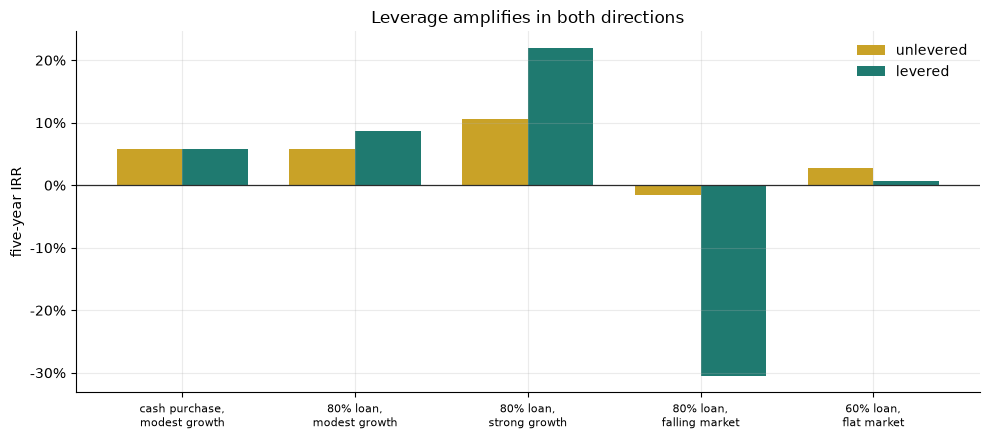

In [13]:
levered = [(r["scenario"], r["irr"], r["unlevered_irr"]) for r in dcf["scenarios"]]
names = [n.replace(", ", ",\n") for n, _, _ in levered]
lev = [v if v is not None else 0 for _, v, _ in levered]
unl = [u if u is not None else v for _, v, u in levered]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - 0.19, unl, 0.38, label="unlevered", color=SAND)
ax.bar(x + 0.19, lev, 0.38, label="levered", color=TEAL)
ax.axhline(0, color=GRAPHITE, linewidth=0.9)
ax.set_xticks(x, names, fontsize=8)
ax.set_ylabel("five-year IRR")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Leverage amplifies in both directions")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Forecast, against a benchmark

Any model can draw a line past the end of a chart. The question is whether it beats the cheapest
sensible alternative — here a seasonal naive forecast, scored on a held-out final year that neither
it nor the model saw.

In [14]:
f = result("forecast.json")
s = f["summary"]

print(f"{s['areas_forecast']} areas forecast, {s['areas_skipped']} refused for thin history")
print(
    f"  beats the naive on {s['areas_beating_naive']}/{s['areas_compared']} areas "
    f"({s['win_rate']:.1%})"
)
print(
    f"  median backtest error   model {s['median_model_mape']:.1%}, "
    f"naive {s['median_naive_mape']:.1%}"
)
print("  target from the plan    at least 60% of areas")
print(f"  met: {'yes' if s['win_rate'] >= 0.60 else 'no'}")

86 areas forecast, 0 refused for thin history
  beats the naive on 77/86 areas (89.5%)
  median backtest error   model 10.1%, naive 15.2%
  target from the plan    at least 60% of areas
  met: yes


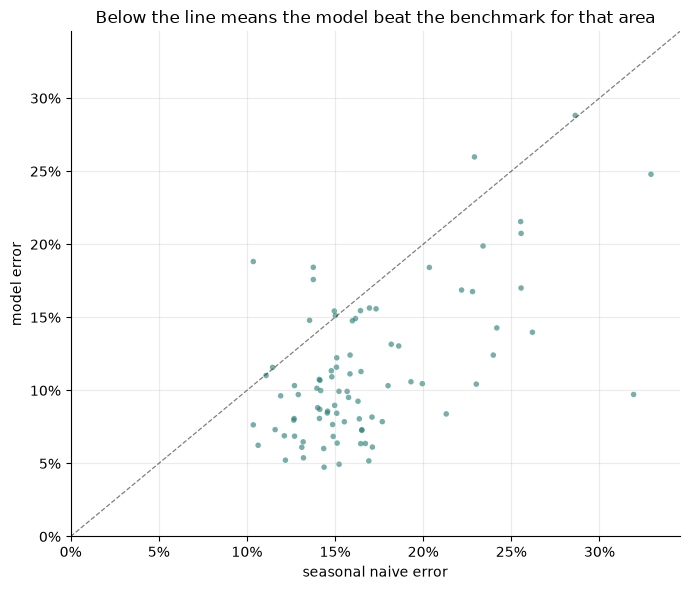

In [15]:
model_errs = [a["backtest_mape"] for a in f["areas"] if a["backtest_mape"] is not None]
naive_errs = [a["naive_mape"] for a in f["areas"] if a["naive_mape"] is not None]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(naive_errs, model_errs, s=16, alpha=0.6, color=TEAL, edgecolor="none")
lim = max(model_errs + naive_errs) * 1.05
ax.plot([0, lim], [0, lim], color=GRAPHITE, linestyle="--", linewidth=0.9, alpha=0.6)
ax.set_xlabel("seasonal naive error")
ax.set_ylabel("model error")
ax.set_title("Below the line means the model beat the benchmark for that area")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

## 7. Risk and anomalies

The risk score is a judgement, not a measurement, so its weights live in
`config/risk_weights.yaml` and the component breakdown is always shown beside the total. A risk
number that cannot be taken apart is one nobody should act on.

In [16]:
r = result("risk.json")
a, s = r["anomalies"], r["summary"]

print(f"{a['flagged']:,} of {a['total_transactions']:,} transactions flagged ({a['rate']:.2%})")
for rule, count in a["by_rule"].items():
    print(f"    {rule:<26} {count:>8,}")
print()
print(f"{s['areas_scored']} areas scored, {s['areas_unscored']} refused as too thin")
print(f"median risk score {s['median_score']:.0f} out of 100")
print()
print("  weights")
for spec in r["weights"]["components"].values():
    print(f"    {spec['label']:<28} {spec['weight']:.0%}")

1,740 of 120,346 transactions flagged (1.45%)
    price out of line             1,204
    resold within 90 days           544
    exactly round price               0

86 areas scored, 0 refused as too thin
median risk score 19 out of 100

  weights
    Off-plan exposure            25%
    Developer concentration      15%
    Price volatility             30%
    Illiquidity                  20%
    Anomaly density              10%


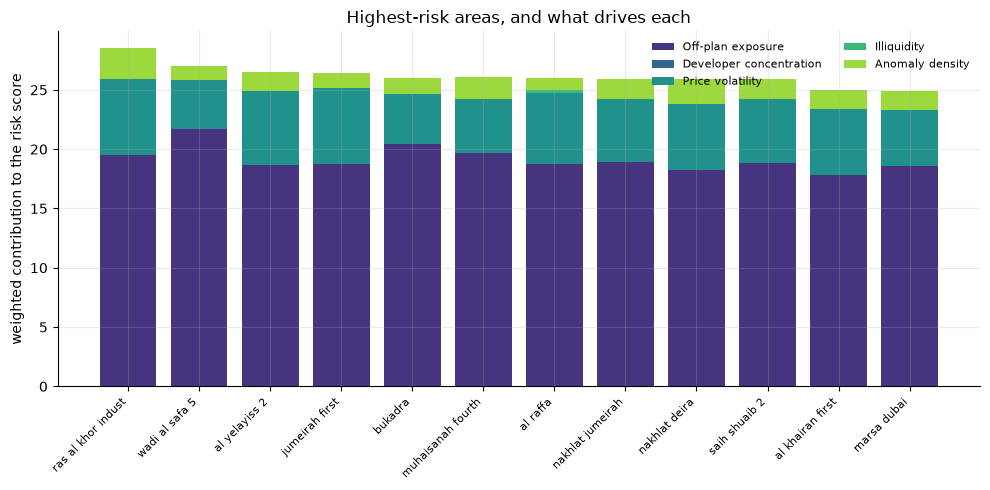

In [17]:
scored = [x for x in r["areas"] if x["score"] is not None]
top = sorted(scored, key=lambda x: -x["score"])[:12]
components = list(r["weights"]["components"])
labels = [r["weights"]["components"][c]["label"] for c in components]

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(top))
palette = plt.cm.viridis(np.linspace(0.15, 0.85, len(components)))
for comp, label, colour in zip(components, labels, palette, strict=True):
    weight = r["weights"]["components"][comp]["weight"]
    vals = np.array([(x["components"].get(comp) or 0) * weight for x in top])
    ax.bar([x["area_key"][:18] for x in top], vals, bottom=bottom, label=label, color=colour)
    bottom += vals
ax.set_ylabel("weighted contribution to the risk score")
ax.set_title("Highest-risk areas, and what drives each")
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Portfolio, and the diversification illusion

Four apartments in four Dubai communities feel diversified and largely are not, because they move
together. The effective number of independent holdings is reported next to the raw count.

In [18]:
p = result("portfolio.json")
y_, div, corr = p["blended_yield"], p["diversification"], p["correlation"]

print(f"{p['holdings']} holdings worth AED {y_['total_value']:,.0f}")
print(f"  blended gross yield        {y_['gross']:.2%}")
print(f"  blended net yield          {y_['net']:.2%}")
if p["projection"]["irr"] is not None:
    print(f"  portfolio IRR              {p['projection']['irr']:.2%}")
print(f"  area concentration (HHI)   {p['concentration']['by_area']['hhi']:.3f}")
print(f"  effective holdings, naive  {div['naive_effective_holdings']:.2f}")
if div.get("correlation_adjusted") is not None:
    print(
        f"  after correlation          {div['correlation_adjusted']:.2f} "
        f"(mean rho {div['mean_correlation']:.2f})"
    )
    print()
    print(f"  {div['note']}")

4 holdings worth AED 16,630,797
  blended gross yield        6.31%
  blended net yield          2.97%
  portfolio IRR              5.29%
  area concentration (HHI)   0.282
  effective holdings, naive  3.54
  after correlation          3.28 (mean rho 0.03)

  Holdings in different Dubai communities still move together, so the correlation adjusted figure is the honest count of independent positions.


In [19]:
d = result("developers.json")
ds = d["summary"]
print(f"{ds['developers']} projects with at least {d['min_transactions']} sales")
print(f"  median premium against their own areas: {ds['median_premium_pct']:+.1f}%")
print(f"  {ds['above_their_areas']} sell above their areas, {ds['below_their_areas']} below")
print()
print(f"  premium definition: {d['premium_definition']}")
print(f"  limitation: {d['limitation']}")

219 projects with at least 30 sales
  median premium against their own areas: +0.0%
  0 sell above their areas, 0 below

  premium definition: median price per square metre against the median for the same area in the same month, so location and timing are held constant
  limitation: the open registry carries a project name but no developer identifier, so projects stand in for developers


## 9. What this does not know

Stated plainly, because a model's limits are part of its output.

- Older registry rows carry no stable unit identifier, so repeat-sale pairs fall back to building,
  bedroom count and floor area. Two different units of identical size in one tower are
  indistinguishable to that key.
- Service charges are an assumption, not a measurement, until DLD's Mollak per-building figures are
  loaded. It is one of the larger inputs to net yield.
- Yields use Ejari medians for an area and unit type, not the actual rent of the specific unit
  being valued.
- Mortgage caps are unverified against a primary source: the Central Bank site refuses automated
  clients. They are shown throughout as editable assumptions rather than as rules.
- Community shapes are curated centroids rendered as hex cells, not true boundaries. No open
  GeoJSON source was reachable.
- Forecasts are statistical projections under stated assumptions. They are not predictions, and
  nothing here is advice.

In [20]:
print(f"Provenance of every figure above: {PROVENANCE}")
if PROVENANCE == "SYNTHETIC":
    meta = json.loads((SYNTHETIC / "synthetic_params.json").read_text())
    print(f"Generator seed: {meta['seed']}")
    print(f"Rows: {meta['n_transactions']:,} transactions, {meta['n_rent_contracts']:,} contracts")
    print()
    print(meta["warning"])

Provenance of every figure above: SYNTHETIC
Generator seed: 217
Rows: 120,346 transactions, 90,000 contracts

Generated data. Structure is plausible so the models can be exercised; the levels are invented and are not claims about the Dubai market. Never cite a number derived from this as a fact about Dubai.
